# AMM Simulator — Prototype Notebook

This notebook runs the prototype in order:

1. Install & imports
2. AMM class + JAX verification
3. Single episode rollout
4. Batch rollout (vmap)
5. Basic result visualization

## 0. Install dependencies

In [7]:
# Run once. Restart kernel after install if needed.
!pip install jax jaxlib chex matplotlib -q

/opt/anaconda3/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Imports

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath("."))
import importlib
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import amm_sim.scoring
import amm_sim.spec
import amm_sim.types
import amm_sim.arb
import amm_sim.engine
import amm_sim.env
import amm_sim.amms.constant_product
import amm_sim.amms.linear

importlib.reload(amm_sim.scoring)
importlib.reload(amm_sim.spec)
importlib.reload(amm_sim.types)
importlib.reload(amm_sim.arb)
importlib.reload(amm_sim.amms.constant_product)
importlib.reload(amm_sim.amms.linear)
importlib.reload(amm_sim.engine)
importlib.reload(amm_sim.env)

from amm_sim.spec import AMMSpec, marginal_ask, marginal_bid
from amm_sim.types import SimParams
from amm_sim.scoring import compute_edge
from amm_sim.env import make_env
from amm_sim.amms.constant_product import (
    CONSTANT_PRODUCT_AMM, CPParams,
    verify_jax_compatibility,
)

print("Modules reloaded.")
print("JAX version :", jax.__version__)
print("JAX devices :", jax.devices())

Modules reloaded.
JAX version : 0.7.1
JAX devices : [CpuDevice(id=0)]


## 2. Phase 2 — CP AMM JAX verification

Confirms that `jit`, `vmap`, and `grad` all work on the CP AMM before running any simulation.

In [9]:
verify_jax_compatibility()

CP AMM (asymmetric fees) — all JAX compatibility checks passed.


## 3. Simulation parameters

In [10]:
# Two competing CP AMMs with different fees
params_30bps = CPParams(
    fee_plus=0.003,
    fee_minus=0.003,
    init_x=100.0,
    init_y=10_000.0,
)

params_20bps = CPParams(
    fee_plus=0.002,
    fee_minus=0.002,
    init_x=100.0,
    init_y=10_000.0,
)

sim_params = SimParams(
    sigma=0.001,       # GBM volatility per step
    num_steps=1_000,   # steps per episode
    max_orders=16,     # max retail orders per step (Poisson clipped)
    lam=0.8,           # Poisson arrival rate
    mu=1.0,            # LogNormal mean for order size
    sigma_ln=0.5,      # LogNormal std
    phi=0.0,           # inventory penalty (0 = pure edge)
)

# Build environment with two identical CP AMMs (30 bps each)
env = make_env(
    amm_specs  = [CONSTANT_PRODUCT_AMM, CONSTANT_PRODUCT_AMM],
    amm_params = [params_30bps, params_30bps],
)

print("Environment ready.")

Environment ready.


## 4. Phase 3 — Single episode rollout

In [11]:
key = jax.random.PRNGKey(0)
final_state, traj = env.rollout(key, sim_params)

# traj is a CycleRecord with shape (num_steps,) per field
arb_edge    = np.array(traj.arb_edge)
retail_edge = np.array(traj.retail_edge)
total_edge  = np.array(traj.total_edge)
fair_price  = np.array(traj.fair_price)

print(f"Episode summary:")
print(f"  Total edge  : {total_edge.sum():.4f}")
print(f"  Arb edge    : {arb_edge.sum():.4f}")
print(f"  Retail edge : {retail_edge.sum():.4f}")
print(f"  Arb always <= 0: {bool((arb_edge <= 1e-6).all())}")

Episode summary:
  Total edge  : 1846.8716
  Arb edge    : -11868.5918
  Retail edge : 13715.4629
  Arb always <= 0: True


### 4.1 Plot: price path and cumulative edge

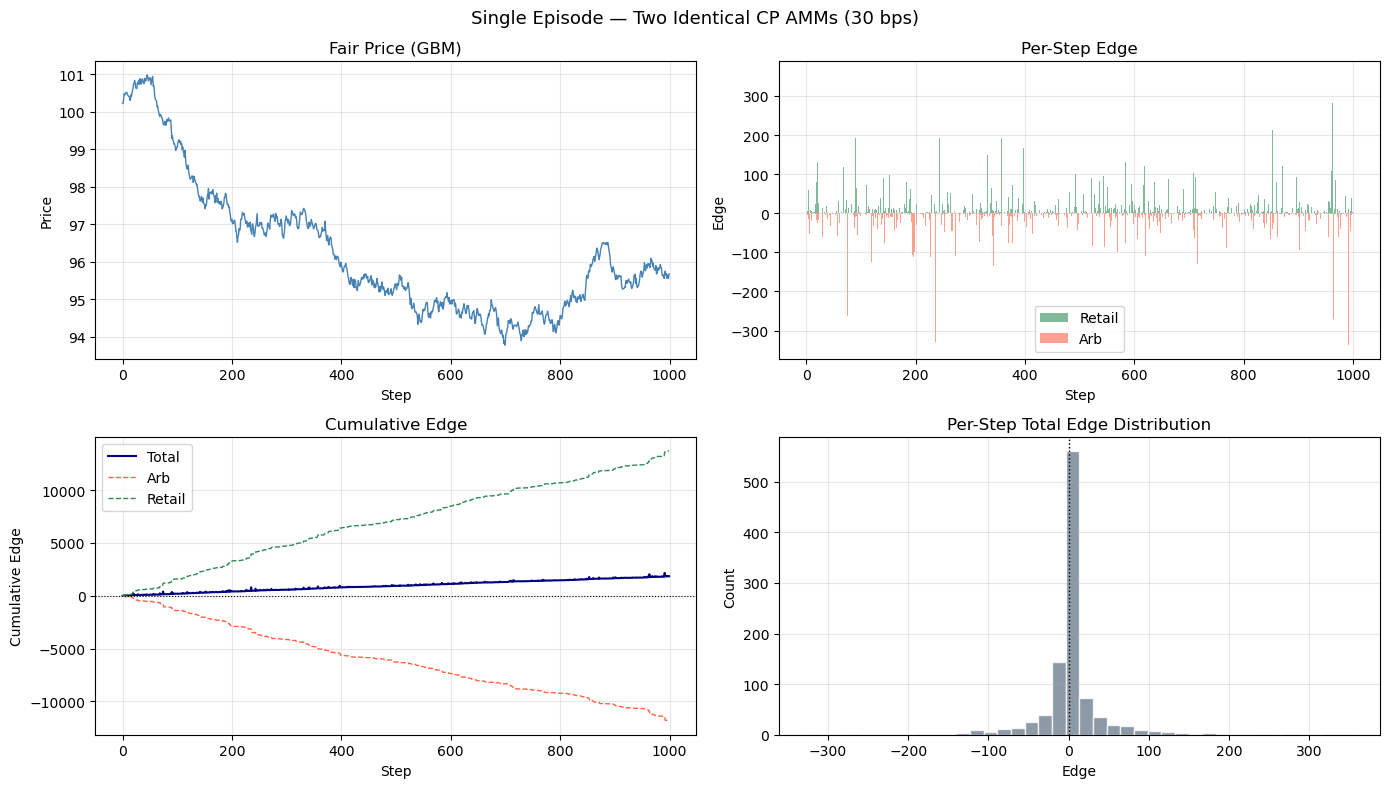

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Single Episode — Two Identical CP AMMs (30 bps)", fontsize=13)

steps = np.arange(len(fair_price))

# ── Fair price path ────────────────────────────────────────────
axes[0, 0].plot(steps, fair_price, color="steelblue", lw=1)
axes[0, 0].set_title("Fair Price (GBM)")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Price")
axes[0, 0].grid(True, alpha=0.3)

# ── Per-step edge breakdown ────────────────────────────────────
axes[0, 1].bar(steps, retail_edge, color="seagreen", alpha=0.6, label="Retail", width=1)
axes[0, 1].bar(steps, arb_edge,    color="tomato",   alpha=0.6, label="Arb",    width=1)
axes[0, 1].set_title("Per-Step Edge")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Edge")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ── Cumulative edge ────────────────────────────────────────────
axes[1, 0].plot(steps, np.cumsum(total_edge),  color="navy",     lw=1.5, label="Total")
axes[1, 0].plot(steps, np.cumsum(arb_edge),    color="tomato",   lw=1,   label="Arb",    linestyle="--")
axes[1, 0].plot(steps, np.cumsum(retail_edge), color="seagreen", lw=1,   label="Retail", linestyle="--")
axes[1, 0].axhline(0, color="black", lw=0.8, linestyle=":")
axes[1, 0].set_title("Cumulative Edge")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("Cumulative Edge")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ── Edge distribution ─────────────────────────────────────────
axes[1, 1].hist(total_edge, bins=40, color="slategray", alpha=0.8, edgecolor="white")
axes[1, 1].axvline(0, color="black", lw=1, linestyle=":")
axes[1, 1].set_title("Per-Step Total Edge Distribution")
axes[1, 1].set_xlabel("Edge")
axes[1, 1].set_ylabel("Count")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Phase 4 — Batch rollout (vmap)

Run 200 independent episodes in parallel.

In [13]:
import time

N_EPISODES = 200
keys = jax.random.split(jax.random.PRNGKey(42), N_EPISODES)

# Warm up JIT
_ = env.batch_rollout(keys[:4], sim_params)
jax.block_until_ready(_)

# Timed run
t0 = time.time()
final_states, trajs = env.batch_rollout(keys, sim_params)
jax.block_until_ready((final_states, trajs))
t1 = time.time()

total_steps = N_EPISODES * sim_params.num_steps
print(f"{N_EPISODES} episodes × {sim_params.num_steps} steps = {total_steps:,} total steps")
print(f"Wall time : {t1-t0:.3f}s  ({total_steps/(t1-t0):,.0f} steps/sec)")

200 episodes × 1000 steps = 200,000 total steps
Wall time : 36.365s  (5,500 steps/sec)


### 5.1 Check: arb edge always <= 0 across all episodes

In [14]:
# trajs fields have shape (N_EPISODES, num_steps)
batch_arb    = np.array(trajs.arb_edge)      # (200, 1000)
batch_retail = np.array(trajs.retail_edge)   # (200, 1000)
batch_total  = np.array(trajs.total_edge)    # (200, 1000)

# Per-episode sums
ep_arb    = batch_arb.sum(axis=1)    # (200,)
ep_retail = batch_retail.sum(axis=1) # (200,)
ep_total  = batch_total.sum(axis=1)  # (200,)

print("Arb edge always <= 0:", bool((batch_arb <= 1e-6).all()))
print()
print(f"{'Metric':<25} {'Mean':>10}  {'Std':>10}  {'Min':>10}  {'Max':>10}")
print("-" * 68)
for name, arr in [("Total edge / episode", ep_total),
                  ("Arb edge / episode",   ep_arb),
                  ("Retail edge / episode",ep_retail)]:
    print(f"{name:<25} {arr.mean():>10.4f}  {arr.std():>10.4f}  "
          f"{arr.min():>10.4f}  {arr.max():>10.4f}")

Arb edge always <= 0: True

Metric                          Mean         Std         Min         Max
--------------------------------------------------------------------
Total edge / episode       1972.8353    107.9536   1696.0645   2338.4663
Arb edge / episode        -12612.5195   1303.0746  -16710.5176  -9589.7832
Retail edge / episode     14585.3555   1383.4512  11285.8477  18925.6758


### 5.2 Plot: distribution of total edge across episodes

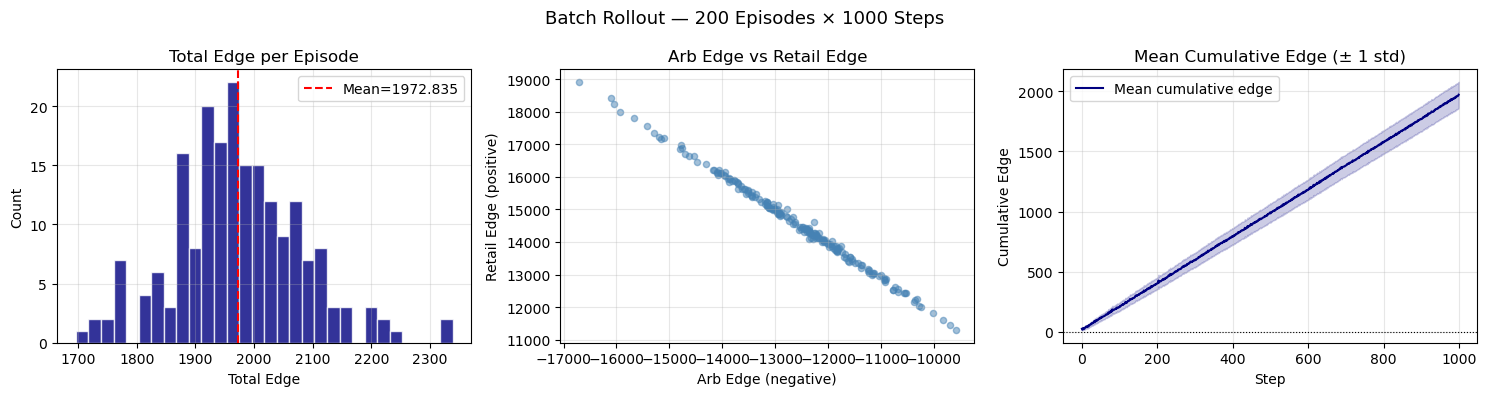

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Batch Rollout — {N_EPISODES} Episodes × {sim_params.num_steps} Steps", fontsize=13)

# Total edge distribution
axes[0].hist(ep_total, bins=30, color="navy", alpha=0.8, edgecolor="white")
axes[0].axvline(ep_total.mean(), color="red", lw=1.5, linestyle="--", label=f"Mean={ep_total.mean():.3f}")
axes[0].set_title("Total Edge per Episode")
axes[0].set_xlabel("Total Edge")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Arb vs retail scatter
axes[1].scatter(ep_arb, ep_retail, alpha=0.5, color="steelblue", s=20)
axes[1].set_title("Arb Edge vs Retail Edge")
axes[1].set_xlabel("Arb Edge (negative)")
axes[1].set_ylabel("Retail Edge (positive)")
axes[1].grid(True, alpha=0.3)

# Mean cumulative edge across all episodes
mean_cum = batch_total.mean(axis=0).cumsum()
std_cum  = batch_total.sum(axis=1).std()
axes[2].plot(mean_cum, color="navy", lw=1.5, label="Mean cumulative edge")
axes[2].fill_between(
    np.arange(len(mean_cum)),
    mean_cum - std_cum * np.sqrt(np.arange(1, len(mean_cum)+1) / sim_params.num_steps),
    mean_cum + std_cum * np.sqrt(np.arange(1, len(mean_cum)+1) / sim_params.num_steps),
    alpha=0.2, color="navy"
)
axes[2].axhline(0, color="black", lw=0.8, linestyle=":")
axes[2].set_title("Mean Cumulative Edge (± 1 std)")
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Cumulative Edge")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Two AMMs with different fees

Pool 0: 20 bps (lower fee, attracts more retail flow)
Pool 1: 30 bps (normalizer)

In [16]:
params_20bps = CPParams(fee_plus=0.002, fee_minus=0.002)
params_30bps = CPParams(fee_plus=0.003, fee_minus=0.003)

env2 = make_env(
    amm_specs  = [CONSTANT_PRODUCT_AMM, CONSTANT_PRODUCT_AMM],
    amm_params = [params_20bps, params_30bps],
)

keys2 = jax.random.split(jax.random.PRNGKey(7), 200)
final2, trajs2 = env2.batch_rollout(keys2, sim_params)
jax.block_until_ready((final2, trajs2))

ep_total2 = np.array(trajs2.total_edge).sum(axis=1)
ep_arb2   = np.array(trajs2.arb_edge).sum(axis=1)
ep_ret2   = np.array(trajs2.retail_edge).sum(axis=1)

print("Pool 0 (20 bps agent) vs Pool 1 (30 bps normalizer)")
print(f"  Mean total edge : {ep_total2.mean():.4f}")
print(f"  Mean arb edge   : {ep_arb2.mean():.4f}")
print(f"  Mean retail edge: {ep_ret2.mean():.4f}")

Pool 0 (20 bps agent) vs Pool 1 (30 bps normalizer)
  Mean total edge : 1651.4012
  Mean arb edge   : -12736.9688
  Mean retail edge: 14388.3701


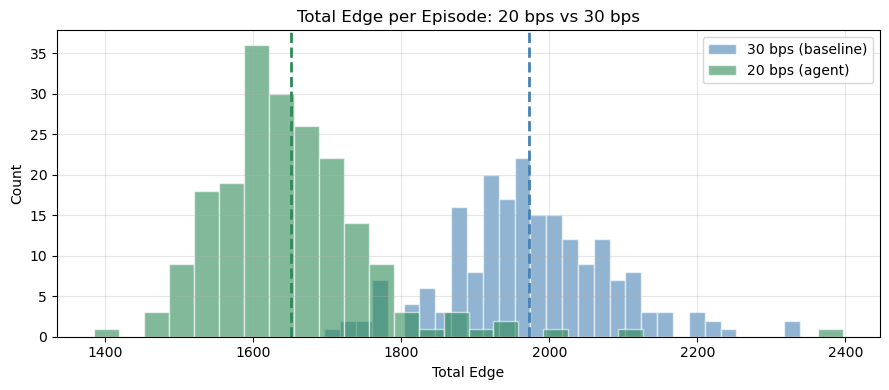

In [17]:
# Compare 20 bps vs 30 bps total edge distributions
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(ep_total,  bins=30, alpha=0.6, color="steelblue", label="30 bps (baseline)", edgecolor="white")
ax.hist(ep_total2, bins=30, alpha=0.6, color="seagreen",  label="20 bps (agent)",   edgecolor="white")
ax.axvline(ep_total.mean(),  color="steelblue", lw=2, linestyle="--")
ax.axvline(ep_total2.mean(), color="seagreen",  lw=2, linestyle="--")
ax.set_title("Total Edge per Episode: 20 bps vs 30 bps")
ax.set_xlabel("Total Edge")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()